50.825688073394495
45.38461538461539 of the winning teams chose batting first
53.85714285714286 of the winning teams chose fielding first


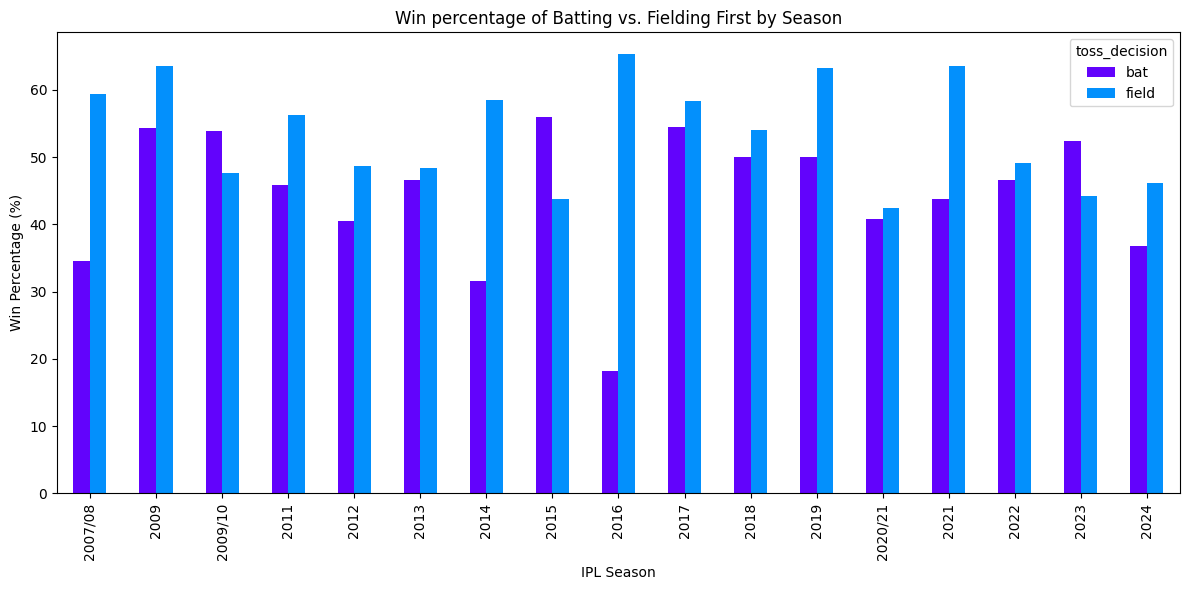

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/matches.csv")

# edge case handling
df = df.dropna(subset=['winner'])
df = df[df['result'] != 'tie']

# Toss Impact
match_winner = (df["toss_winner"]==df["winner"]).sum()
total_matches = len(df)
percentage_of_matches_won = (match_winner/total_matches) * 100
print(percentage_of_matches_won)


# Decision Impact
bat = df[df["toss_decision"]=='bat']
field = df[df["toss_decision"]=='field']
bat_wins = (bat["toss_winner"]==bat["winner"]).sum()
field_wins = (field["toss_winner"]==field["winner"]).sum()
bat_match_winner = (bat_wins/len(bat)) * 100
field_match_winner = (field_wins/len(field)) * 100
print(f"{bat_match_winner } of the winning teams chose batting first")
print(f"{field_match_winner} of the winning teams chose fielding first")

# Visualization
df['toss_match_win'] = df['toss_winner'] == df['winner']
seasonal_win = df.groupby(['season', 'toss_decision'])['toss_match_win'].mean() * 100
plot_data = seasonal_win.unstack()
plot_data.plot(kind='bar', figsize=(12, 6), color=['#6203fc', '#0390fc'])
plt.title("Win percentage of Batting vs. Fielding First by Season")
plt.xlabel("IPL Season")
plt.ylabel("Win Percentage (%)")
plt.tight_layout()
plt.show()